# Five-layer architecture: interface examples

This notebook is the executable usage guide for the modular architecture. The raw and standard data layers are implemented; later sections define the intended public interfaces.

## 1. Raw data layer

`RawDataManager` reads source metadata from a catalog, resolves paths under `data/`, and reports availability without interpreting source-specific columns. `source_id` is a stable dataset key, not a dynamically generated Python variable.

In [1]:
from pathlib import Path
import gc

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

from src.raw import RawDataManager
from src.standard import DATASET_IDS, StandardDataManager, time_bounds
from src.mapping import SpatiotemporalMappingManager
from src.case import PowerSystemCaseManager
from src.app import UnitCommitmentApplication

plt.ioff()  # Figures are shown only by an explicit display() call.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

project_root = Path.cwd()
data_root = project_root / "data"

In [2]:
raw_data = RawDataManager(project_root / "config/raw_data_sources.csv", data_root)
_catalog = raw_data._catalog
_check = raw_data.check()
_prepare = raw_data.prepare()
_source_id = "gem_integrated_power"
_file_path = raw_data.get_file(_source_id)

## 2. Standard data layer

`StandardDataManager` exposes the stable dataset IDs `spatial`, `network`, `generator`, `storage`, `parameter`, `load`, `population`, and `resource`. Source-specific processing is controlled by `config/standard_data.toml`; changing source dependencies does not change these public IDs.

In [3]:
standard_data = StandardDataManager(project_root / "config/standard_data.toml", raw_data=raw_data)
_check = standard_data.check()
# _build = standard_data.build()
_id = "parameter"
_sample = standard_data.load(_id)
_schema = _sample.schema

In [4]:
_para = standard_data.load("parameter")
_count = _para.count()
resolved, candidates = _para.resolve(
    standard_data.load("generator").iloc[10000],
    ["minimum_output_pu", "ramp_up_pu_per_hour"],
    dataset_id="generator",
    include_candidates=True
)
display(_count)

,group,records,names,sources,datasets,classes,derived_records
0,technical,1317,86,4,3,15,49
1,economic,706,17,3,4,15,19
2,environmental,63,9,1,1,6,0
3,others,0,0,0,0,0,0


## 3. Spatiotemporal mapping layer

`SpatiotemporalMappingManager` creates clipped standard cells, conservative load/resource remapping, the largest connected network, and explicit cell/bus relationships. Run `mapping.build()` to regenerate all outputs; this example only checks existing results.

In [5]:
mapping = SpatiotemporalMappingManager(project_root / "config/mapping.toml", standard_data)
_check = mapping.check()
# _build = mapping.build()
_id = "network"
_schema = mapping.schema(_id)
_sample = mapping.load(_id)

## 4. System case layer

`PowerSystemCaseManager` filters and reconnects mapped data, resolves parameters, aggregates assets, aligns time series, and returns one backend-neutral `PowerSystemCase`. PyPSA conversion is an optional final adapter.

In [6]:
case_manager = PowerSystemCaseManager(project_root / "config/case.toml", mapped_data=mapping, standard_data=standard_data)
# power_system_case = case_manager.build()
power_system_case = case_manager.load()
# display(power_system_case.validation)

In [7]:
# display(case_manager.load("network").bus)

## 5. Case visualization

Case plots share the standard/mapping API and visual style. They return figures without displaying or saving them.

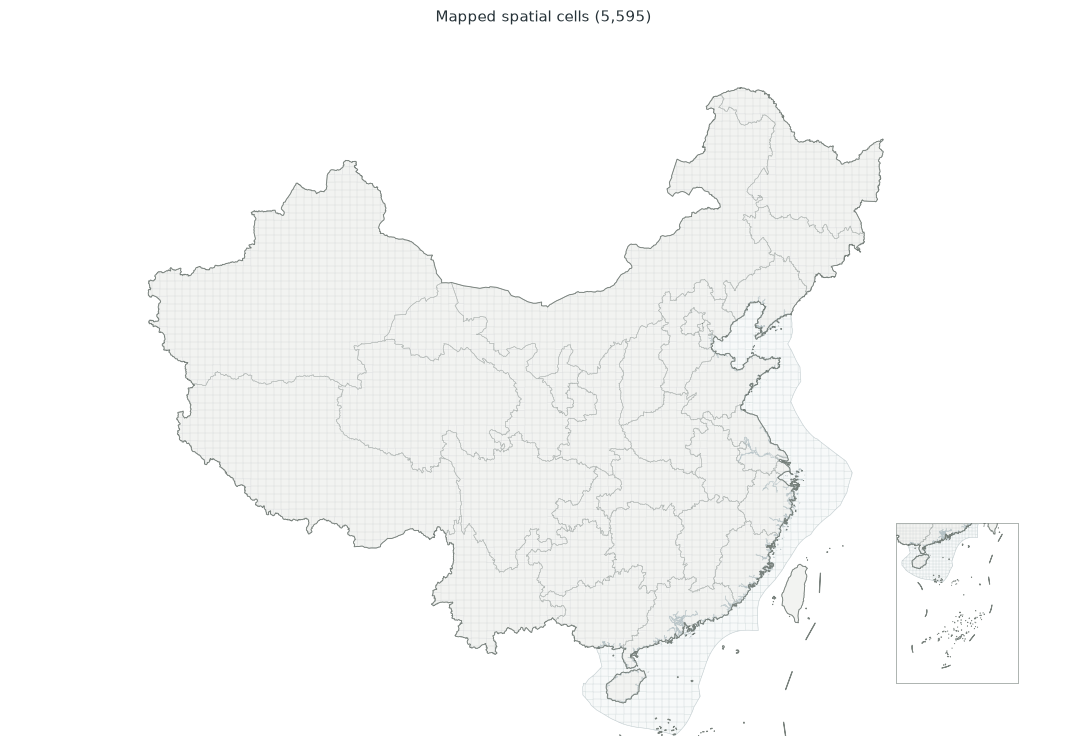

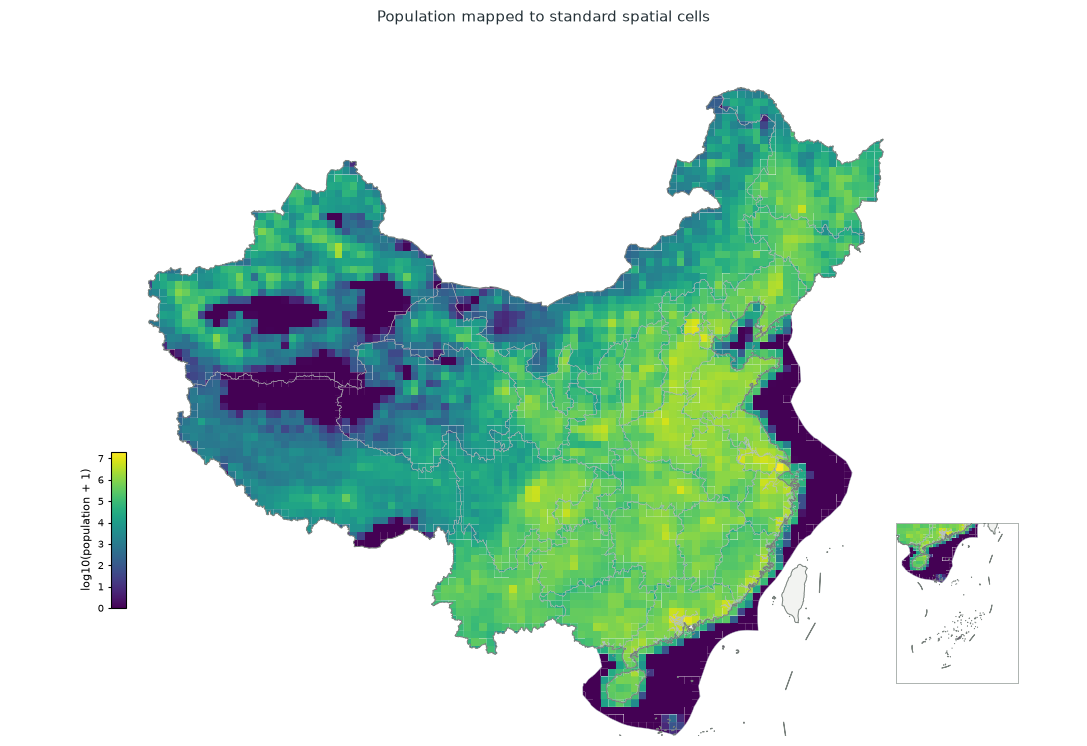

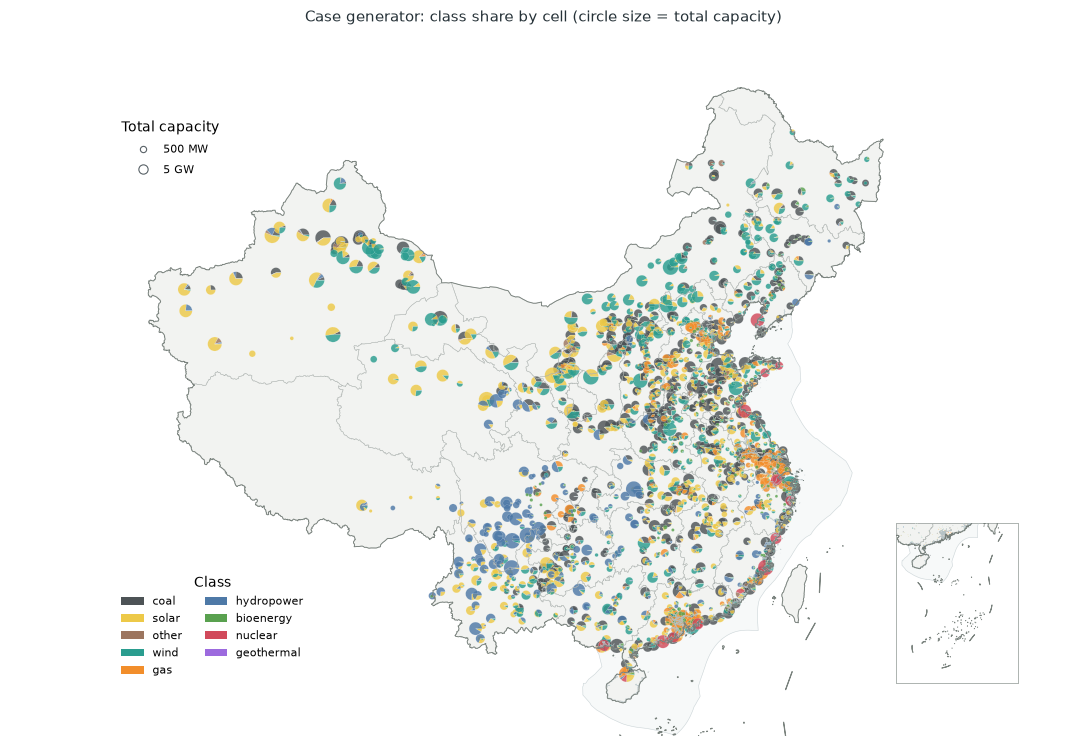

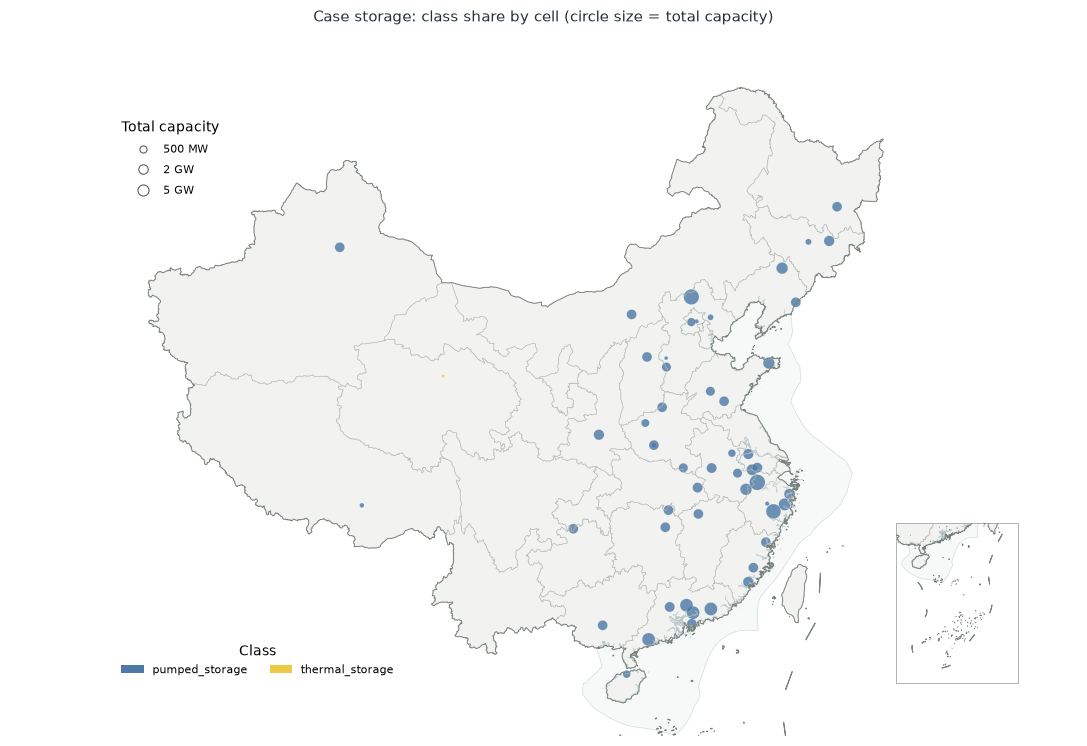

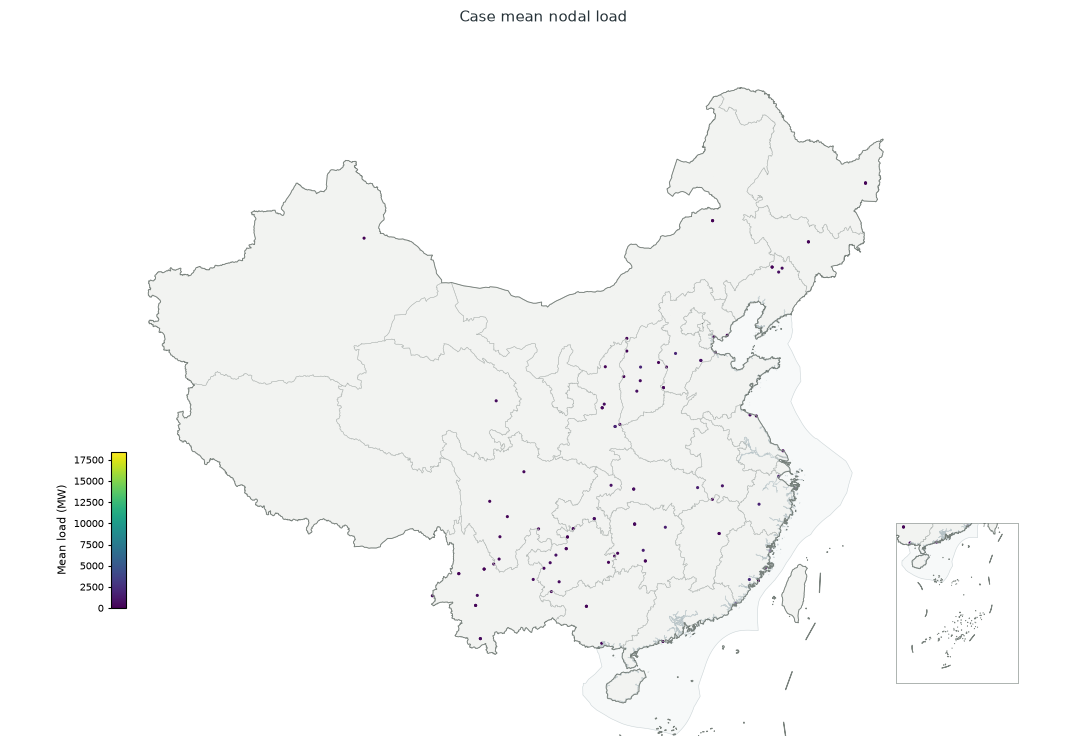

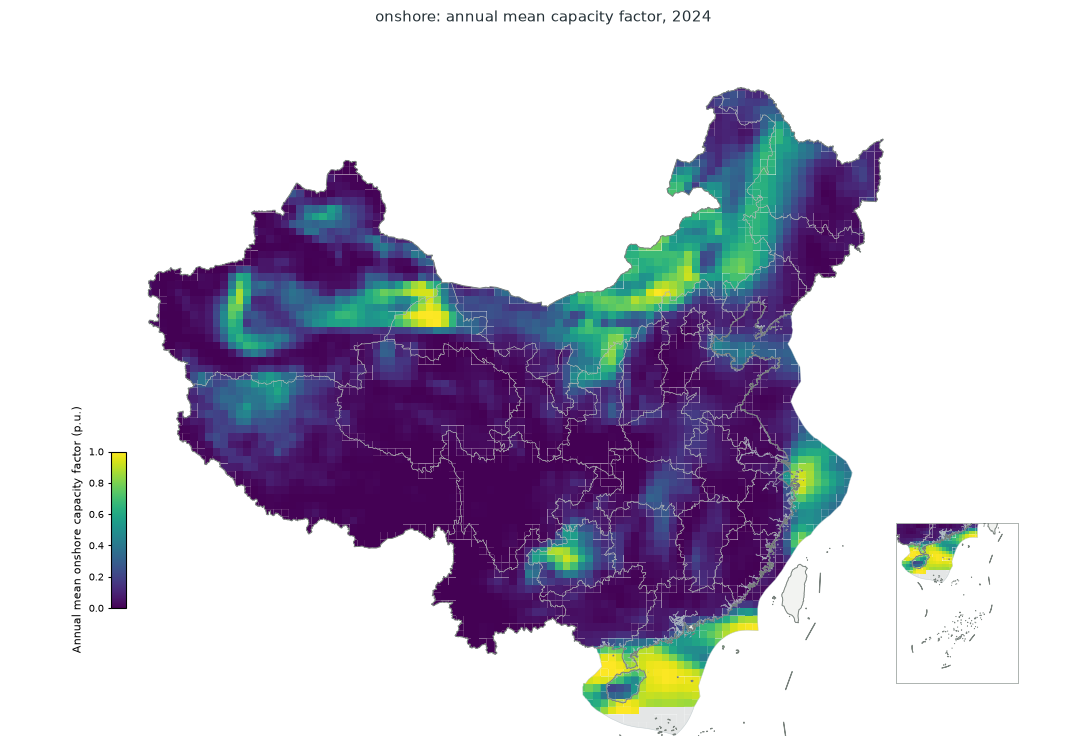

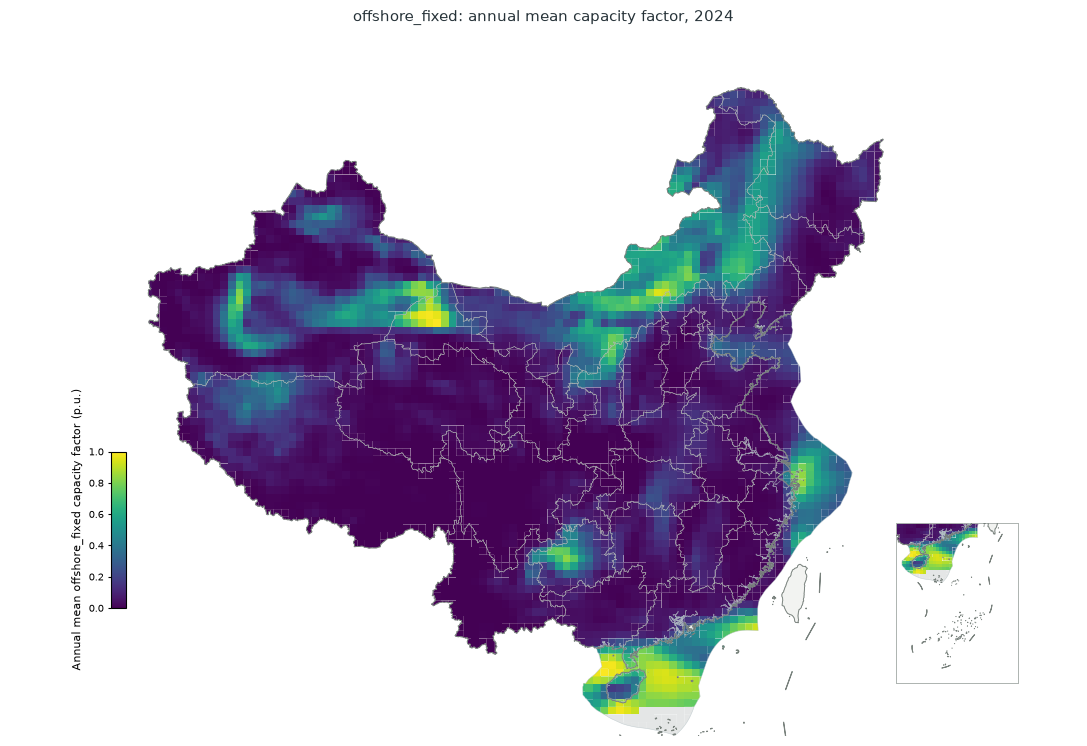

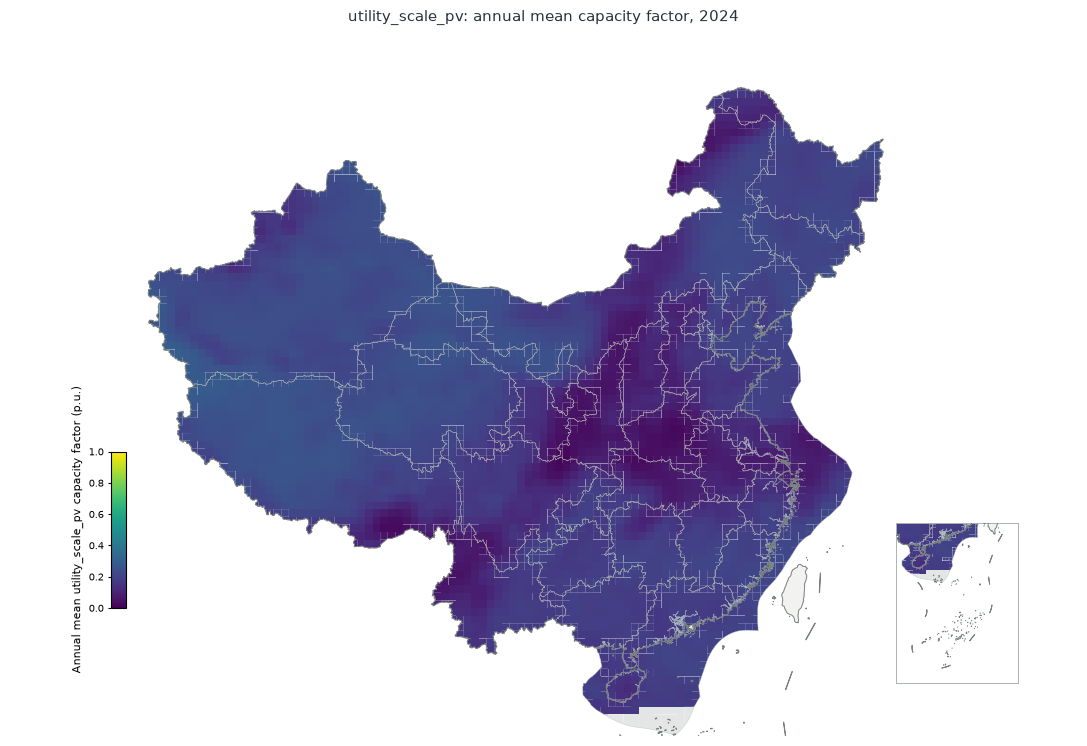

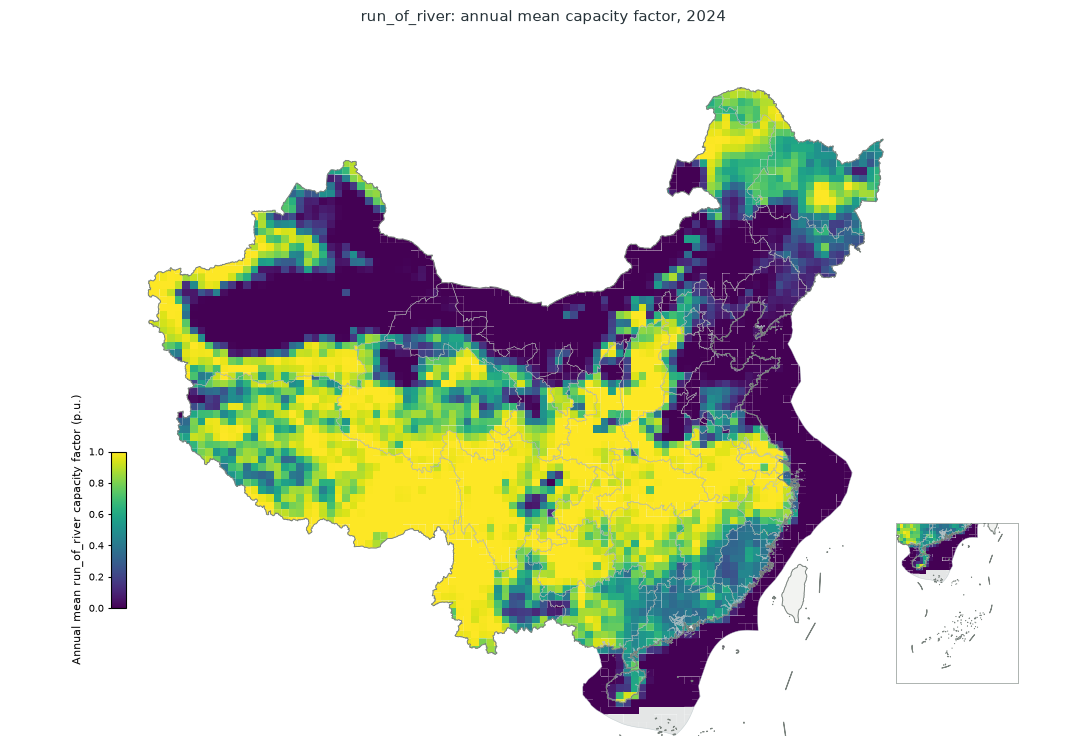

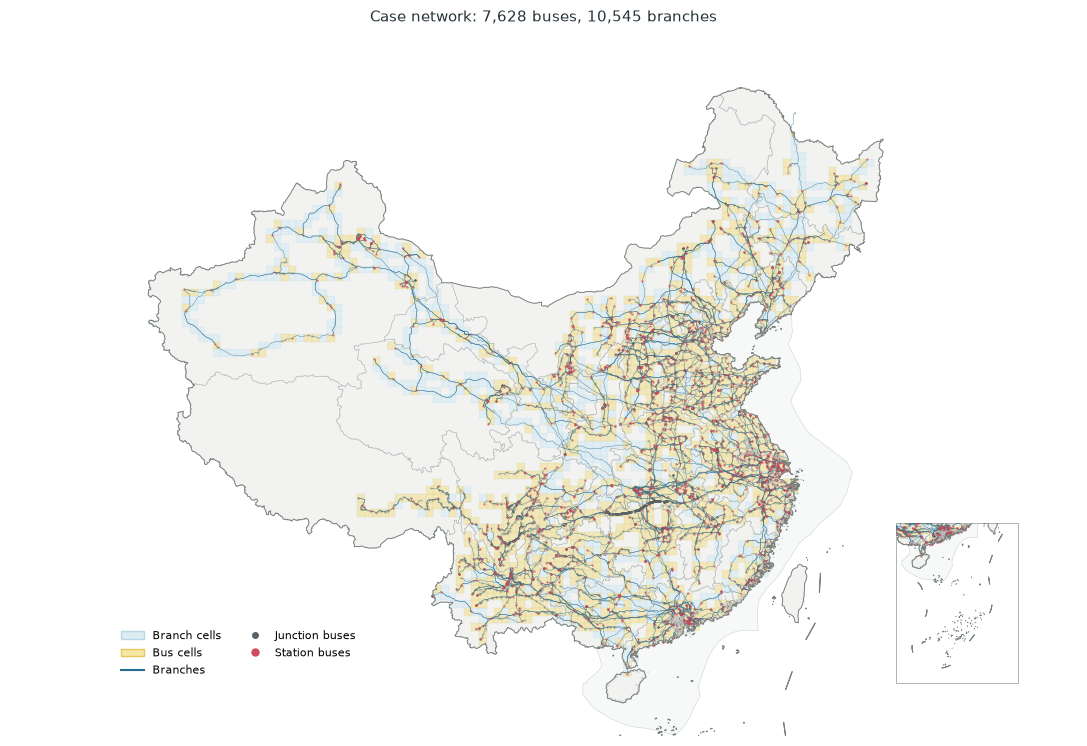

167901

In [9]:
_plot_crs = mapping.options["metric_crs"]

# Plot mapped datasets in a deterministic order and close each displayed figure.
for _id in (
    "spatial",
    "population",
    "generator",
    "storage",
    "load",
    "resource",
    "network"
):
    # _figures = mapping.plot(_id, year=2024, map_crs=_plot_crs)
    _figures = case_manager.plot(_id, year=2024, map_crs=_plot_crs)
    if not isinstance(_figures, dict):
        _figures = {_id: _figures}
    for _figure in _figures.values():
        display(_figure)
        plt.close(_figure)
del _figures, _figure
gc.collect()

# # Case, mapping, and standard layers expose the same core plot options.
# _dataset_id = "generator"
# _plot_options = {
#     "start": "2024-07-15 00:00",  # Used by case load.
#     "end": "2024-07-15 23:00",
#     "map_crs": mapping.options["metric_crs"],
#     "spatial_levels": None,      # All levels; e.g. ["province"] or ["marine_zone"].
#     "china_inset": None,         # Automatic for China; False disables the inset.
# }
# _save_directory = None              # e.g. project_root / "outputs" / "figures"
# _save_dpi = 300

# _figures = case_manager.plot(_dataset_id, **_plot_options)
# if not isinstance(_figures, dict):
#     _figures = {_dataset_id: _figures}
# for _name, _figure in _figures.items():
#     display(_figure)
#     if _save_directory is not None:
#         _save_directory.mkdir(parents=True, exist_ok=True)
#         _figure.savefig(
#             _save_directory / f"{_dataset_id}_{_name}.png",
#             dpi=_save_dpi,
#             bbox_inches="tight",
#         )
#     plt.close(_figure)

## 6. Continuous UC/ED application

The current aggregated case uses continuous dispatch variables. The PyPSA application solves the selected period and returns a colored production-simulation figure.

,value
solver_status,ok
termination_condition,optimal
is_optimal,True
objective,4306468340.386916
snapshots,168
load_mwh,204665927.098561
load_shedding_mwh,13279.030913
load_shedding_share,0.000065
storage_discharge_mwh,157548.709567
storage_charge_mwh,207648.001488


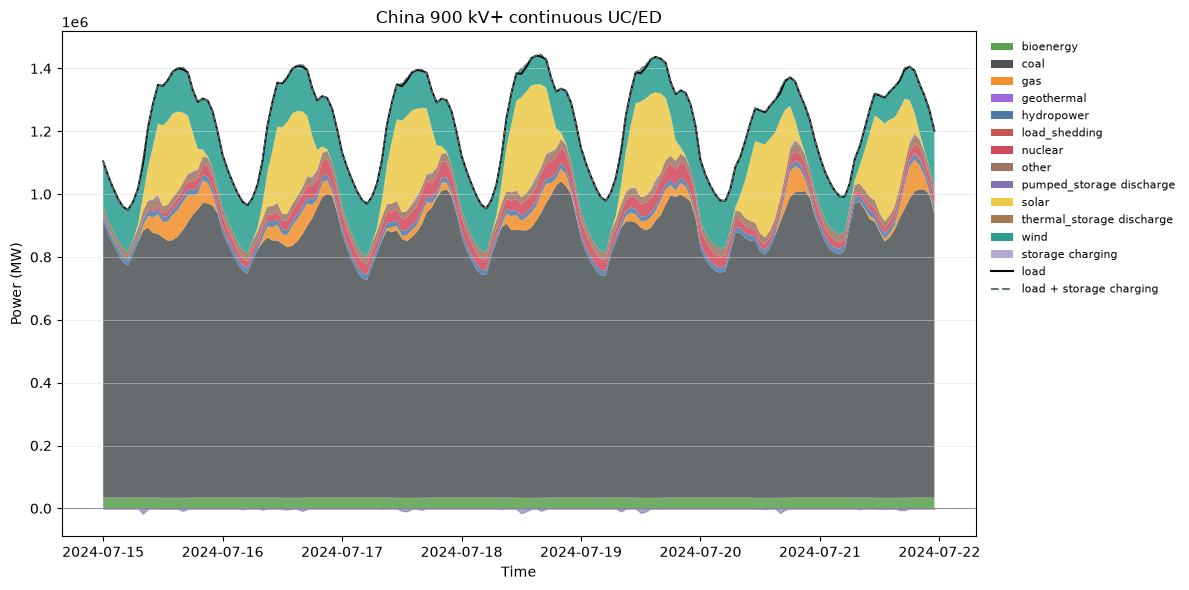

In [8]:
uc_application = UnitCommitmentApplication(
    power_system_case, project_root / "config/uc.toml"
)
# uc_result = uc_application.run()  # Rebuild only after selecting an application-scale case.
uc_result = uc_application.load()
display(uc_result.summary.to_frame())

uc_figure = uc_result.plot(
    start="2024-07-15 00:00",
    end="2024-07-21 23:00",
    title="China 900 kV+ continuous UC/ED",
)
display(uc_figure)
plt.close(uc_figure)